# ANÁLISE EXPLORATÓRIA DE DADOS - HACKATHON
# Dataset: Bank Customer Churn (Kaggle - gauravtopre)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
# Carregando os dados

df = pd.read_csv('/workspaces/hackathon-churn-prediction/dados/Bank_Customer_Churn_Prediction.csv')

print("Dataset carregado com sucesso!")



Dataset carregado com sucesso!


In [4]:
# INSPEÇÃO INICIAL
# Visão geral do DataFrame
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Informações sobre o DataFrame
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
#  Qualidade dos dados: nulos e duplicatas 
print("=" * 50)
print("QUALIDADE DOS DADOS")
print("=" * 50)

# Valores nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
qualidade = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print("\nValores Nulos por Coluna:")
print(qualidade[qualidade['Nulos'] > 0] if qualidade['Nulos'].sum() > 0 
      else "  Nenhum valor nulo encontrado!")

# Duplicatas
n_duplicatas = df.duplicated().sum()
print(f"\nRegistros duplicados: {n_duplicatas}")
if n_duplicatas > 0:
    print("   Há duplicatas — considerar remoção antes do treino")
else:
    print("   Nenhuma duplicata encontrada!")

# Valores únicos por coluna
print("\n Valores únicos por coluna:")
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col:<25} {n:>6} valores únicos")

QUALIDADE DOS DADOS

Valores Nulos por Coluna:
  Nenhum valor nulo encontrado!

Registros duplicados: 0
   Nenhuma duplicata encontrada!

 Valores únicos por coluna:
  customer_id                10000 valores únicos
  credit_score                 460 valores únicos
  country                        3 valores únicos
  gender                         2 valores únicos
  age                           70 valores únicos
  tenure                        11 valores únicos
  balance                     6382 valores únicos
  products_number                4 valores únicos
  credit_card                    2 valores únicos
  active_member                  2 valores únicos
  estimated_salary            9999 valores únicos
  churn                          2 valores únicos


**CONHECENDO OS DADOS**
- customer_id : Identificador único do cliente (tipo um ID)
- credit_score : Score de crédito do cliente
- country : País de residência do cliente
- gender : Sexo do cliente
- age : Idade do cliente
- tenure : Tempo de assinatura
- balance : Saldo da conta
- products_number : Quantidade de produtos/serviços do banco que o cliente usa
- credit_card : Se o cliente possui cartão de crédito (0 = não, 1 = sim)
- active_member : Se o cliente está ativo (0 = não, 1 = sim)
- estimated_salary : Salário estimado do cliente
- churn : Se o cliente saiu ou não

In [5]:
# Valores estatísticos para os dados numéricos
df.select_dtypes(include='number').describe()



,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Dando uma olhada nas colunas que contêm dados categóricos
df.select_dtypes(exclude=np.number)

,country,gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


In [7]:
# Procurando por linhas duplicadas
print(df.duplicated().sum())

0


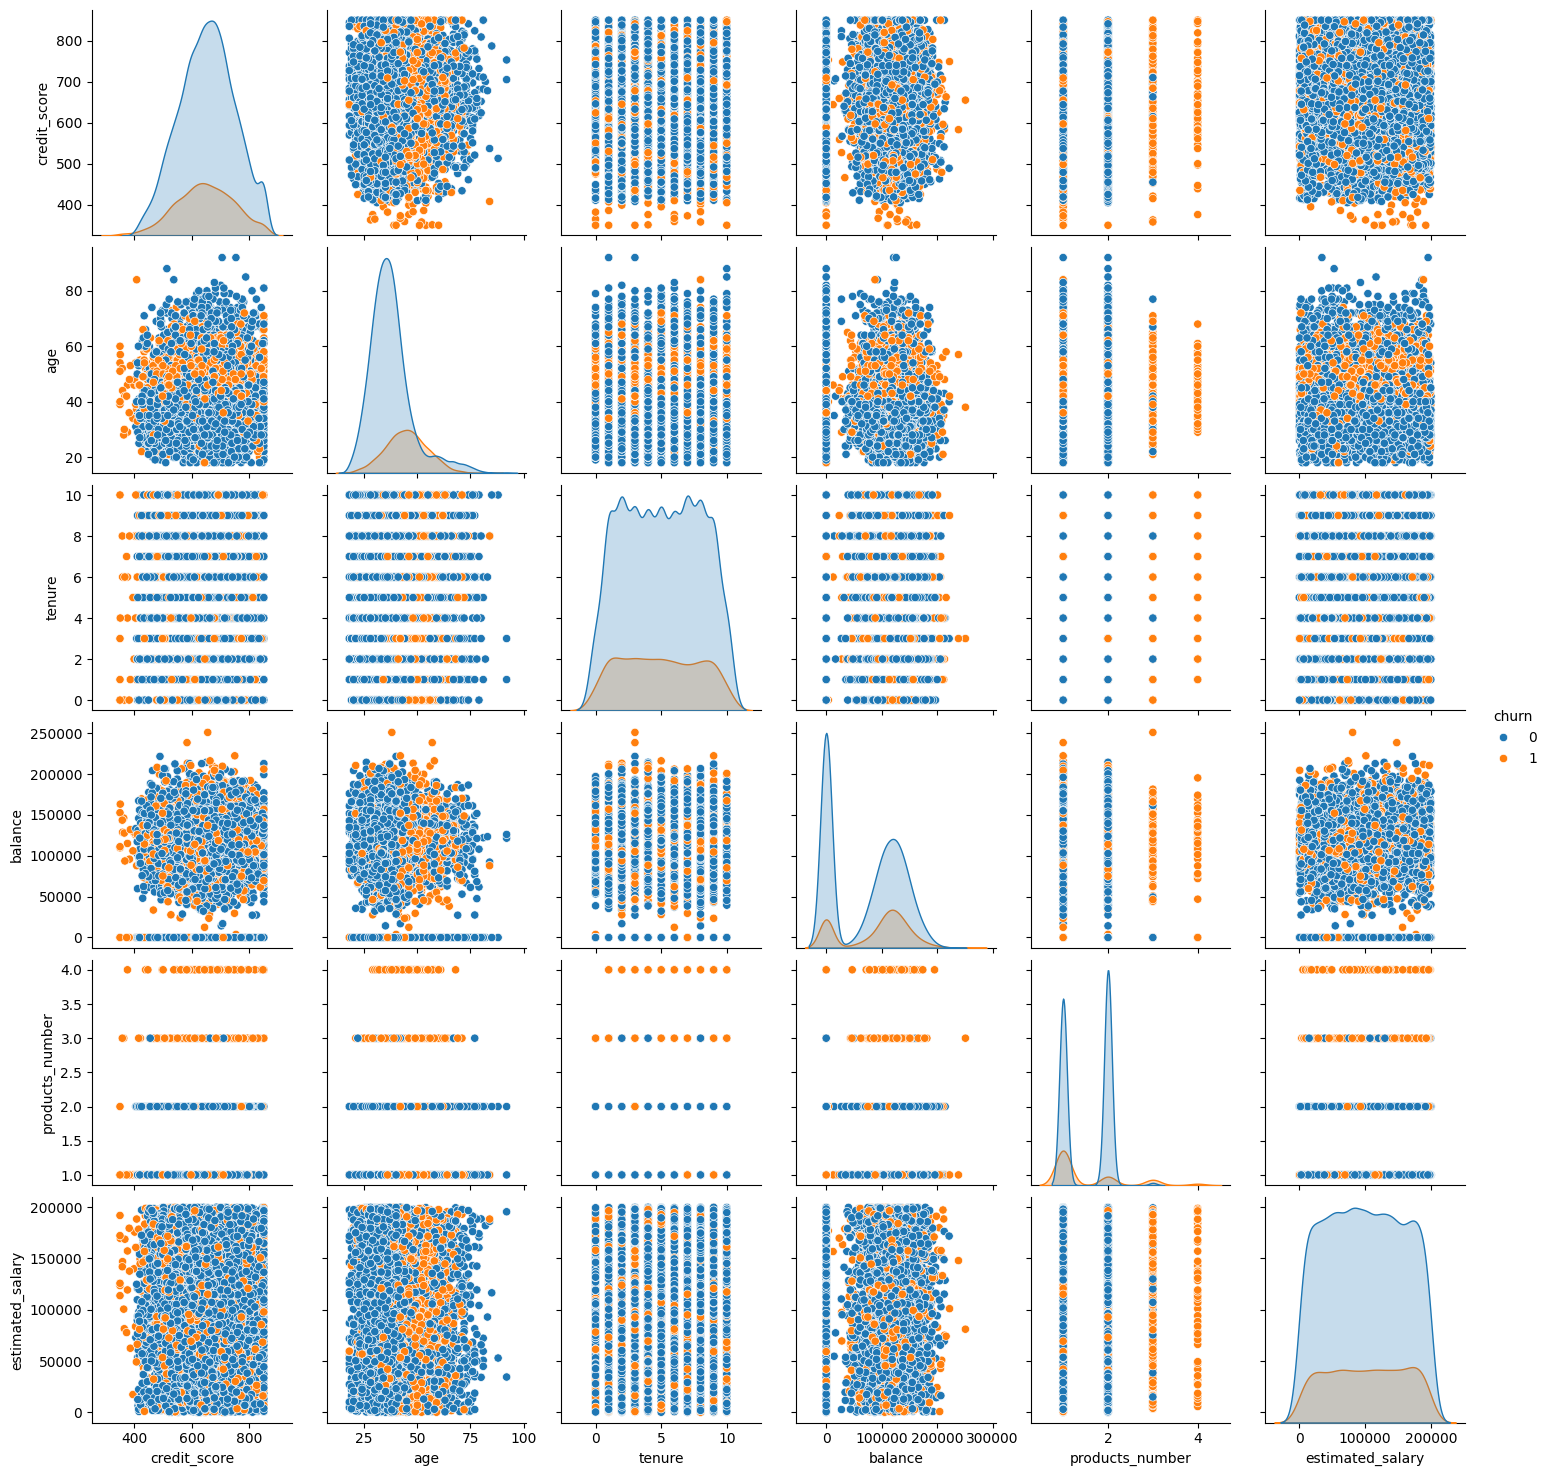

In [8]:
sns.pairplot(
    df[['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'churn']],
    hue='churn',
    diag_kind='kde'
)
plt.show()

## Verificando se os dados categóricos estão textualmente padronizados

In [9]:
# Quantitativos por categoria
df['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
# Porcentagem
df['country'].value_counts(normalize=True)*100

country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

In [11]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
df['gender'].value_counts(normalize=True)*100

gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

In [13]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

**OBSERVAÇÕES**
- As variáveis (colunas/features) apresentam tipagens adequadas para análise, com separação consistente entre dados numéricos e categóricos.
- Não foram identificados valores ausentes (missing values) no dataset.
- Não há presença de linhas duplicadas, indicando consistência estrutural dos dados.
- O dataset contempla clientes de três países — França, Alemanha e Espanha — com forte desbalanceamento na variável country, sobretudo com predominância de clientes da França. Esse fator deve ser considerado em análises comparativas e modelagem.
- Em relação às estatísticas descritivas, a maioria das variáveis apresenta distribuição aproximadamente simétrica (média próxima da mediana), como credit_score, tenure e estimated_salary. No entanto, algumas variáveis demonstram assimetria relevante, como:
balance.
- A variável age apresenta valor mínimo igual a 18 anos, o que é consistente com a regra de negócio esperada (clientes maiores de idade), não indicando inconsistências aparentes.
- Variável balance apresentou um quantitativo expressivo com o valor 0 (25%).

## Procurando por Outliers


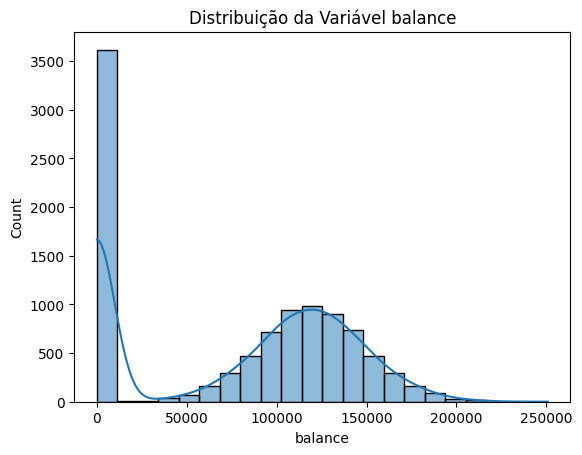

In [15]:
# Saldo (balance)
sns.histplot(data=df, x = "balance", kde=True).set_title("Distribuição da Variável balance")
plt.show()


In [16]:
# Quantidade de clientes com balance=0
(df['balance'] == 0).sum()

np.int64(3617)

<Axes: xlabel='tenure', ylabel='balance'>

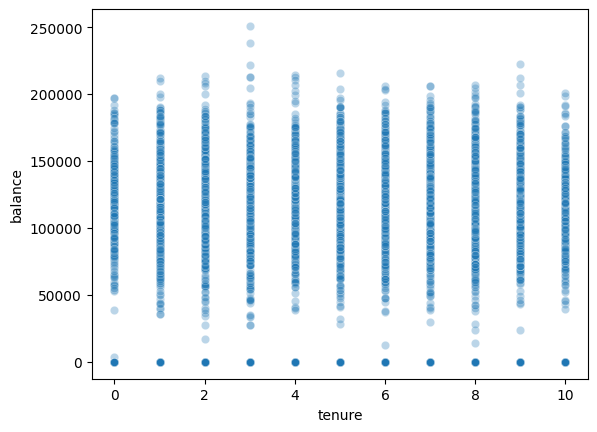

In [17]:
# existe alguma relação entre balance x tenure?
sns.scatterplot(data=df, x="tenure", y="balance", alpha=0.3)


In [18]:
# Quantitativo de balance = 0 por ano(tenure)
df[df['balance'] == 0]['tenure'].value_counts()

tenure
7     386
2     382
5     374
4     369
6     367
8     363
9     360
3     352
1     349
10    178
0     137
Name: count, dtype: int64

In [19]:
#  Função para identificar outliers
"""
outliers = são considerados Outliers os valores que estão abaixo do mínimo, 
sendo valores menores que o mínimo (Q1–1,5 * IIQ) ou acima do máximo (Q3 + 1,5 * IIQ).
"""

def detect_outliers(df, coluna):
    dados = df[coluna].dropna()
    
    # Quartis
    q1 = np.percentile(dados, 25)
    q3 = np.percentile(dados, 75)
    iqr = q3 - q1
    
    # Limites
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Filtrando outliers
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    
    # Output
    print(f"Coluna: {coluna}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {outliers.shape[0]}")
    
    return outliers

In [20]:
#Procurando por outliers em colunas númericas e não binárias
colunas = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

for col in colunas:
    print("-" * 40)
    detect_outliers(df, col)

----------------------------------------
Coluna: credit_score
Limite inferior: 383.00
Limite superior: 919.00
Quantidade de outliers: 15
----------------------------------------
Coluna: age
Limite inferior: 14.00
Limite superior: 62.00
Quantidade de outliers: 359
----------------------------------------
Coluna: tenure
Limite inferior: -3.00
Limite superior: 13.00
Quantidade de outliers: 0
----------------------------------------
Coluna: balance
Limite inferior: -191466.36
Limite superior: 319110.60
Quantidade de outliers: 0
----------------------------------------
Coluna: products_number
Limite inferior: -0.50
Limite superior: 3.50
Quantidade de outliers: 60
----------------------------------------
Coluna: estimated_salary
Limite inferior: -96577.10
Limite superior: 296967.45
Quantidade de outliers: 0


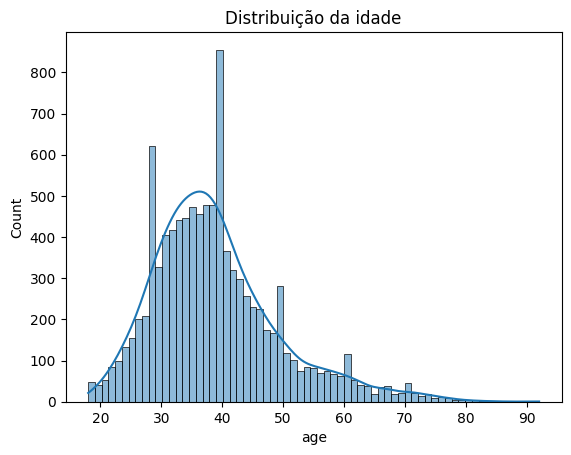

In [21]:
sns.histplot(data=df, x='age', kde=True)
plt.title("Distribuição da idade")
plt.show()

In [22]:
# Idade (age)
# Faixa etária
print("18-24 anos:\t", df[(df["age"] >=18) & (df["age"] <=24)].shape[0])
print("25-34 anos:\t", df[(df["age"] >=25) & (df["age"] <=34)].shape[0])
print("35-44 anos:\t", df[(df["age"] >=35) & (df["age"] <=44)].shape[0])
print("45-59 anos:\t", df[(df["age"] >=45) & (df["age"] <=59)].shape[0])
print("60 ou + anos:\t", df[df["age"] >=60].shape[0]) #idosos

18-24 anos:	 457
25-34 anos:	 3222
35-44 anos:	 3981
45-59 anos:	 1814
60 ou + anos:	 526


In [23]:
# Percentual por faixa etária
total = len(df)

print("18-24 anos:\t", (df[(df["age"] >=18) & (df["age"] <=24)].shape[0] / total) * 100)
print("25-34 anos:\t", (df[(df["age"] >=25) & (df["age"] <=34)].shape[0] / total) * 100)
print("35-44 anos:\t", (df[(df["age"] >=35) & (df["age"] <=44)].shape[0] / total) * 100)
print("45-59 anos:\t", (df[(df["age"] >=45) & (df["age"] <=59)].shape[0] / total) * 100)
print("60 ou + anos:\t", (df[df["age"] >=60].shape[0] / total) * 100)

18-24 anos:	 4.569999999999999
25-34 anos:	 32.22
35-44 anos:	 39.81
45-59 anos:	 18.14
60 ou + anos:	 5.26


In [24]:
# % de clientes que deram churn
bins = [18, 25, 35, 45, 60, 100] #intervalos
labels = ['18-24', '25-34', '35-44', '45-59', '60+']

df['faixa_etaria'] = pd.cut(df['age'], bins=bins, labels=labels, right=False) #right=False → intervalo inclui esquerda e exclui direita
df.groupby('faixa_etaria', observed=True)['churn'].mean() * 100 #observed=True mostra somente as categorias que tiverem valores

faixa_etaria
18-24     8.752735
25-34     7.759156
35-44    17.658880
45-59    49.448732
60+      27.946768
Name: churn, dtype: float64

In [25]:
df.groupby('faixa_etaria', observed=True)['churn'].value_counts()

faixa_etaria  churn
18-24         0         417
              1          40
25-34         0        2972
              1         250
35-44         0        3278
              1         703
45-59         0         917
              1         897
60+           0         379
              1         147
Name: count, dtype: int64

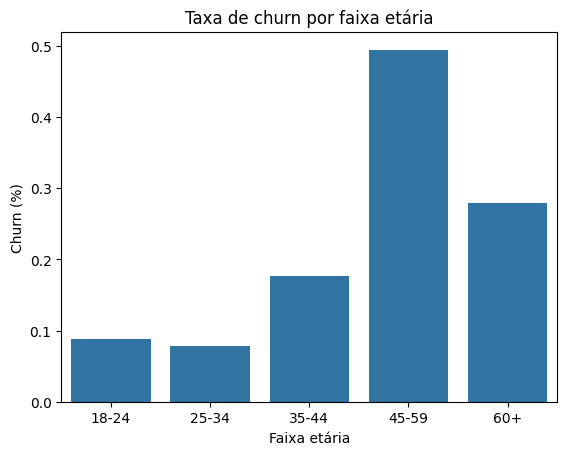

In [26]:
churn_por_idade = df.groupby('faixa_etaria', observed=True)['churn'].mean().reset_index()

sns.barplot(data=churn_por_idade, x='faixa_etaria', y='churn')
plt.title("Taxa de churn por faixa etária")
plt.ylabel("Churn (%)")
plt.xlabel("Faixa etária")
plt.show()

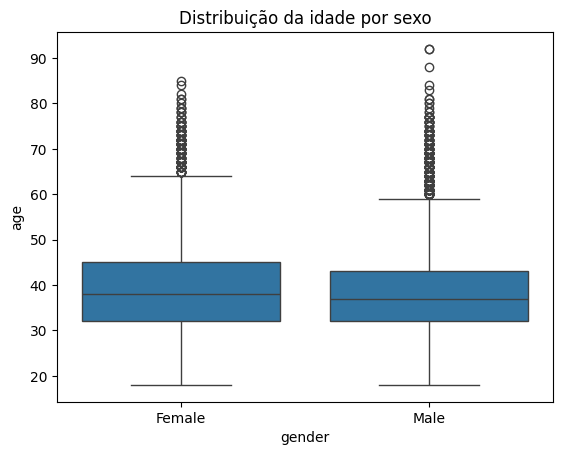

In [27]:
# Distribuição do sexo do cliente conforme faixa etárias
sns.boxplot(data=df, x='gender', y='age')
plt.title("Distribuição da idade por sexo")
plt.show()

In [28]:
#dentro de cada faixa etária, qual % é masculino vs feminino
pd.crosstab(df['faixa_etaria'], df['gender'], normalize='index') * 100

gender,Female,Male
faixa_etaria,,
18-24,44.420131,55.579869
25-34,44.072005,55.927995
35-44,44.486310,55.513690
45-59,50.055127,49.944873
60+,45.817490,54.182510


**OBSERVAÇÕES**
- Aproximadamente 3.617 clientes apresentam saldo (balance) igual a zero, o que pode indicar contas inativas ou clientes com baixa utilização dos serviços bancários.
- A variável balance, embora não apresente outliers segundo o critério do IQR, evidencia uma alta concentração de valores iguais a zero, sugerindo um comportamento estrutural distinto que deve ser considerado separadamente na análise.
- A variável credit_score apresentou baixo número de outliers, indicando distribuição estável e com impacto limitado na análise.
- A variável age apresentou quantidade significativa de valores classificados como outliers pelo método IQR. Contudo, esses valores refletem clientes mais idosos (acima de 62 anos) e não inconsistências nos dados, mas sim um segmento real da população, caracterizando uma distribuição com cauda longa à direita.

- A maior concentração de clientes está nas faixas etárias:
    * 25–34 anos (32,22%)
    * 35–44 anos (39,81%)
      
indicando predominância de clientes em idade economicamente ativa.

- Observa-se que a faixa etária 45–59 anos apresenta a maior taxa de churn (49,44%), sugerindo maior propensão à evasão nesse grupo.
A distribuição da variável gender é equilibrada entre masculino e feminino, não indicando viés significativo de gênero no dataset.


**Análise técnica das variáveis**
- age: 
    * Apresenta assimetria à direita (cauda longa) devido à presença de clientes mais idosos
    * Pode impactar modelos sensíveis a outliers, especialmente regressão linear
    * Recomendação: considerar segmentação por faixas etárias ou transformação da variável

- balance: 
    * Não apresenta outliers pelo critério estatístico (IQR)
    * Contudo, possui problema estrutural relevante devido à alta proporção de valores zero
    * Recomendação: analisar separadamente clientes com saldo zero

- products_number: 
    * Valores considerados outliers correspondem a clientes com maior número de produtos
    * Representam comportamento válido (clientes mais engajados)
    * Não requer tratamento como erro